In [11]:
# %%
# ============================================================
# CELL 1: Setup and Reproducibility
# ============================================================
import random, torch, platform
import numpy as np

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

print(f"Python: {platform.python_version()}")
print(f"NumPy: {np.__version__}")
print(f"PyTorch: {torch.__version__}")
print(f"✅ Random seed fixed to {SEED}")

Python: 3.11.13
NumPy: 2.2.6
PyTorch: 2.8.0
✅ Random seed fixed to 42


In [12]:
# %%
# ============================================================
# CELL 2: Configuration
# ============================================================
import os

# Target configuration
TARGET_CSV = "flare_euv_targets_3day.csv"
IMG_SIZE = 256  # ← UPGRADED to 256 for better spatial resolution
SAVE_DIR = "preprocessed_data"

# Channel definitions
AIA_CHANNELS = [
    "aia94", "aia131", "aia171", "aia193",
    "aia211", "aia304", "aia335", "aia1600"
]

HMI_CHANNELS = [
    "hmiB_field", "hmiB_incl", "hmiB_azim", 
    "hmiIC", "hmiM"
]

print(f"""
PREPROCESSING CONFIGURATION:
- Target CSV: {TARGET_CSV}
- Image Size: {IMG_SIZE}×{IMG_SIZE}
- AIA Channels: {len(AIA_CHANNELS)}
- HMI Channels: {len(HMI_CHANNELS)}
- Total Channels: {len(AIA_CHANNELS) + len(HMI_CHANNELS)}
- Output Directory: {SAVE_DIR}
""")

# Create output directory
os.makedirs(SAVE_DIR, exist_ok=True)
print(f"✅ Output directory ready: {SAVE_DIR}")


PREPROCESSING CONFIGURATION:
- Target CSV: flare_euv_targets_3day.csv
- Image Size: 256×256
- AIA Channels: 8
- HMI Channels: 5
- Total Channels: 13
- Output Directory: preprocessed_data

✅ Output directory ready: preprocessed_data


In [13]:
# %%
# ============================================================
# CELL 3: Import Libraries
# ============================================================
import glob
import pandas as pd
import cv2
import matplotlib.pyplot as plt
from matplotlib import rcParams
import warnings

warnings.filterwarnings('ignore')

# Set matplotlib style
rcParams.update({
    'font.size': 9,
    'axes.titlesize': 9,
    'axes.labelsize': 8,
    'figure.dpi': 100
})

print("✅ Libraries imported")

✅ Libraries imported


In [14]:
# %%
# ============================================================
# CELL 4: Normalization and Preprocessing Functions
# ============================================================

def normalize_log(img):
    """
    Robust normalization with log stretch
    - Handles NaN, inf values
    - 1-99 percentile clipping
    - Log1p stretch for dynamic range compression
    """
    # Handle invalid values
    img = np.nan_to_num(img, nan=0.0, posinf=0.0, neginf=0.0)
    
    # Get valid pixels for percentile calculation
    valid = img[np.isfinite(img)]
    if len(valid) == 0:
        return np.zeros_like(img)
    
    # Percentile clipping
    lo, hi = np.percentile(valid, [1, 99])
    img = np.clip(img, lo, hi)
    
    # Log stretch
    img = np.log1p(img - lo + 1e-6)
    
    # Normalize to [0, 1]
    img_min, img_max = img.min(), img.max()
    if img_max > img_min:
        img = (img - img_min) / (img_max - img_min)
    
    return img.astype(np.float32)


def resize_image(img, size=IMG_SIZE):
    """Resize image using area interpolation (best for downsampling)"""
    return cv2.resize(img, (size, size), interpolation=cv2.INTER_AREA)


def process_frame(frame, flip=False):
    """
    Process a single frame:
    1. Normalize with log stretch
    2. Apply vertical flip if needed (for HMI north-up)
    3. Resize to target size
    """
    # Normalize
    frame = normalize_log(frame)
    
    # Flip for HMI (south→north)
    if flip:
        frame = np.flipud(frame)
    
    # Resize
    frame = resize_image(frame)
    
    return frame

print("✅ Preprocessing functions ready")
print("   - normalize_log: 1-99% clipping + log stretch")
print("   - resize_image: Area interpolation")
print("   - process_frame: Full pipeline with optional flip")

✅ Preprocessing functions ready
   - normalize_log: 1-99% clipping + log stretch
   - resize_image: Area interpolation
   - process_frame: Full pipeline with optional flip


In [15]:
# %%
# ============================================================
# CELL 5: NPZ Aggregation Function (FIXED: Use only first 5 time points)
# ============================================================

def aggregate_npz(folder, channels, flip=False, verbose=False):
    """
    Aggregate multiple .npz files for a flare into temporally-averaged maps.
    
    IMPORTANT: Uses only the first 5 .npz files (chronologically) to exclude
    the T+6hr offset and avoid temporal leakage.
    
    Parameters:
    -----------
    folder : str
        Directory containing .npz files
    channels : list
        List of channel names to extract
    flip : bool
        Whether to flip vertically (for HMI north-up alignment)
    verbose : bool
        Print detailed processing info
    
    Returns:
    --------
    dict : {channel_name: averaged_normalized_resized_array}
    """
    # Find all npz files
    npz_files = sorted(glob.glob(os.path.join(folder, "*.npz")))
    
    if not npz_files:
        if verbose:
            print(f"   ⚠️  No .npz files found in {folder}")
        return {}
    
    # ✅ CRITICAL CHANGE: Use only first 5 files (exclude T+6hr)
    npz_files = npz_files[:5]  # ← CHANGED from using all files
    
    if verbose:
        print(f"   📂 Using first {len(npz_files)} .npz files (excluding T+6hr) in {folder}")
    
    # Accumulator for each channel
    accumulator = {ch: [] for ch in channels}
    
    # Process each file
    for npz_path in npz_files:
        try:
            data = np.load(npz_path)
            
            for channel in channels:
                if channel in data:
                    # Get all temporal frames and average
                    frames = data[channel]
                    
                    # Handle different array shapes
                    if frames.ndim == 2:
                        # Single frame
                        avg_frame = frames
                    elif frames.ndim == 3:
                        # Multiple frames - average along time axis
                        avg_frame = frames.mean(axis=0)
                    else:
                        if verbose:
                            print(f"   ⚠️  Unexpected shape for {channel}: {frames.shape}")
                        continue
                    
                    # Process frame
                    processed = process_frame(avg_frame, flip=flip)
                    accumulator[channel].append(processed)
                    
        except Exception as e:
            if verbose:
                print(f"   ⚠️  Error loading {npz_path}: {e}")
            continue
    
    # Average all processed frames for each channel
    result = {}
    for channel, frame_list in accumulator.items():
        if len(frame_list) > 0:
            result[channel] = np.mean(np.stack(frame_list, axis=0), axis=0)
            if verbose:
                print(f"   ✅ {channel}: averaged {len(frame_list)} time points")
        else:
            if verbose:
                print(f"   ⚠️  {channel}: no valid data")
    
    return result

print("✅ NPZ aggregation function ready (uses first 5 time points only)")
print("   ⚠️  Excludes 6th file (T+6hr offset) to avoid temporal leakage")

✅ NPZ aggregation function ready (uses first 5 time points only)
   ⚠️  Excludes 6th file (T+6hr offset) to avoid temporal leakage


In [ ]:
# %% dont use 
# ============================================================
# CELL 5: NPZ Aggregation Function
# ============================================================

def aggregate_npz(folder, channels, flip=False, verbose=False):
    """
    Aggregate multiple .npz files for a flare into daily-averaged maps.
    
    Parameters:
    -----------
    folder : str
        Directory containing .npz files
    channels : list
        List of channel names to extract
    flip : bool
        Whether to flip vertically (for HMI north-up alignment)
    verbose : bool
        Print detailed processing info
    
    Returns:
    --------
    dict : {channel_name: averaged_normalized_resized_array}
    """
    # Find all npz files
    npz_files = sorted(glob.glob(os.path.join(folder, "*.npz")))
    
    if not npz_files:
        if verbose:
            print(f"   ⚠️  No .npz files found in {folder}")
        return {}
    
    if verbose:
        print(f"   📂 Found {len(npz_files)} .npz files in {folder}")
    
    # Accumulator for each channel
    accumulator = {ch: [] for ch in channels}
    
    # Process each file
    for npz_path in npz_files:
        try:
            data = np.load(npz_path)
            
            for channel in channels:
                if channel in data:
                    # Get all temporal frames and average
                    frames = data[channel]
                    
                    # Handle different array shapes
                    if frames.ndim == 2:
                        # Single frame
                        avg_frame = frames
                    elif frames.ndim == 3:
                        # Multiple frames - average along time axis
                        avg_frame = frames.mean(axis=0)
                    else:
                        if verbose:
                            print(f"   ⚠️  Unexpected shape for {channel}: {frames.shape}")
                        continue
                    
                    # Process frame
                    processed = process_frame(avg_frame, flip=flip)
                    accumulator[channel].append(processed)
                    
        except Exception as e:
            if verbose:
                print(f"   ⚠️  Error loading {npz_path}: {e}")
            continue
    
    # Average all processed frames for each channel
    result = {}
    for channel, frame_list in accumulator.items():
        if len(frame_list) > 0:
            result[channel] = np.mean(np.stack(frame_list, axis=0), axis=0)
            if verbose:
                print(f"   ✅ {channel}: averaged {len(frame_list)} exposures")
        else:
            if verbose:
                print(f"   ⚠️  {channel}: no valid data")
    
    return result

print("✅ NPZ aggregation function ready")

✅ NPZ aggregation function ready


In [16]:
# %%
# ============================================================
# CELL 6: Load Target CSV and Build Dataset
# ============================================================

# Load targets
print(f"\n{'='*70}")
print("LOADING TARGETS")
print(f"{'='*70}")

targets = pd.read_csv(TARGET_CSV)
print(f"✅ Loaded {len(targets)} flares from {TARGET_CSV}")
print(f"\nTarget columns: {list(targets.columns)}")
print(f"\nFirst few entries:")
print(targets.head())

# Initialize storage
X_list = []  # Will store (13, IMG_SIZE, IMG_SIZE) arrays
Y_list = []  # Will store (3,) arrays
skipped_flares = []
successful_flares = []

print(f"\n{'='*70}")
print("PROCESSING FLARES")
print(f"{'='*70}")

for idx, row in targets.iterrows():
    flare_id = row["flare_id"]
    print(f"\n[{idx+1}/{len(targets)}] Processing: {flare_id}")
    
    # Define paths
    aia_dir = os.path.join(flare_id, "full_disk", "npz_aia")
    hmi_dir = os.path.join(flare_id, "full_disk", "npz_hmi")
    
    # Check if directories exist
    if not os.path.exists(aia_dir):
        print(f"   ❌ AIA directory not found: {aia_dir}")
        skipped_flares.append((flare_id, "AIA directory missing"))
        continue
    
    if not os.path.exists(hmi_dir):
        print(f"   ❌ HMI directory not found: {hmi_dir}")
        skipped_flares.append((flare_id, "HMI directory missing"))
        continue
    
    # Aggregate AIA channels (no flip)
    print(f"   📡 Processing AIA channels...")
    aia_maps = aggregate_npz(aia_dir, AIA_CHANNELS, flip=False, verbose=False)
    
    # Aggregate HMI channels (with flip for north-up)
    print(f"   🧲 Processing HMI channels...")
    hmi_maps = aggregate_npz(hmi_dir, HMI_CHANNELS, flip=True, verbose=False)
    
    # Check if we have all channels
    missing_aia = [ch for ch in AIA_CHANNELS if ch not in aia_maps]
    missing_hmi = [ch for ch in HMI_CHANNELS if ch not in hmi_maps]
    
    if missing_aia:
        print(f"   ❌ Missing AIA channels: {missing_aia}")
        skipped_flares.append((flare_id, f"Missing AIA: {missing_aia}"))
        continue
    
    if missing_hmi:
        print(f"   ❌ Missing HMI channels: {missing_hmi}")
        skipped_flares.append((flare_id, f"Missing HMI: {missing_hmi}"))
        continue
    
    # Stack channels: AIA first, then HMI
    try:
        aia_stack = np.stack([aia_maps[ch] for ch in AIA_CHANNELS], axis=0)
        hmi_stack = np.stack([hmi_maps[ch] for ch in HMI_CHANNELS], axis=0)
        combined = np.concatenate([aia_stack, hmi_stack], axis=0)
        
        # Verify shape
        expected_shape = (len(AIA_CHANNELS) + len(HMI_CHANNELS), IMG_SIZE, IMG_SIZE)
        assert combined.shape == expected_shape, f"Shape mismatch: {combined.shape} vs {expected_shape}"
        
        # Extract targets
        targets_values = row[["EUV_T0", "EUV_T1", "EUV_T2"]].values.astype(np.float32)
        
        # Store
        X_list.append(combined)
        Y_list.append(targets_values)
        successful_flares.append(flare_id)
        
        print(f"   ✅ Success! Shape: {combined.shape}, Targets: {targets_values}")
        
    except Exception as e:
        print(f"   ❌ Error during stacking: {e}")
        skipped_flares.append((flare_id, f"Stacking error: {e}"))
        continue

# Convert to arrays
X = np.array(X_list, dtype=np.float32)
Y = np.array(Y_list, dtype=np.float32)

print(f"\n{'='*70}")
print("PROCESSING COMPLETE")
print(f"{'='*70}")
print(f"✅ Successfully processed: {len(successful_flares)} flares")
print(f"❌ Skipped: {len(skipped_flares)} flares")
print(f"\nFinal dataset shapes:")
print(f"  X: {X.shape} (flares, channels, height, width)")
print(f"  Y: {Y.shape} (flares, horizons)")


LOADING TARGETS
✅ Loaded 33 flares from flare_euv_targets_3day.csv

Target columns: ['flare_id', 'flare_time', 'EUV_T0', 'EUV_T0_std', 'EUV_T1', 'EUV_T1_std', 'EUV_T2', 'EUV_T2_std']

First few entries:
       flare_id           flare_time    EUV_T0  EUV_T0_std    EUV_T1  \
0  AR11158_M6.6  2011-02-13 17:28:00  0.000060    0.000209  0.000062   
1  AR11158_X2.2  2011-02-15 01:44:00  0.000063    0.000320  0.000062   
2  AR11261_M9.3  2011-07-30 02:04:00  0.000062    0.000195  0.000064   
3  AR11429_X5.4  2012-03-07 00:02:00  0.000084    0.000614  0.000080   
4  AR11429_M6.3  2012-03-09 03:22:00  0.000083    0.000238  0.000085   

   EUV_T1_std    EUV_T2  EUV_T2_std  
0    0.000188  0.000063    0.000320  
1    0.000190  0.000064    0.000171  
2    0.000342  0.000067    0.000177  
3    0.000217  0.000083    0.000238  
4    0.000312  0.000081    0.000177  

PROCESSING FLARES

[1/33] Processing: AR11158_M6.6
   📡 Processing AIA channels...
   🧲 Processing HMI channels...
   ✅ Success! Shape

In [17]:
# %%
# ============================================================
# CELL 7: Dataset Statistics and Quality Checks
# ============================================================

print(f"\n{'='*70}")
print("DATASET STATISTICS")
print(f"{'='*70}")

# X statistics (per channel)
print("\nInput (X) Statistics:")
print(f"  Overall min/max: {X.min():.6f} / {X.max():.6f}")
print(f"  Overall mean ± std: {X.mean():.6f} ± {X.std():.6f}")

print("\n  Per-channel statistics:")
all_channels = AIA_CHANNELS + HMI_CHANNELS
for i, ch in enumerate(all_channels):
    ch_data = X[:, i, :, :]
    print(f"    {ch:12s}: min={ch_data.min():.4f}, max={ch_data.max():.4f}, " +
          f"mean={ch_data.mean():.4f}, std={ch_data.std():.4f}")

# Y statistics
print("\nTarget (Y) Statistics:")
print(f"  Overall min/max: {Y.min():.6e} / {Y.max():.6e}")
print(f"  Overall mean ± std: {Y.mean():.6e} ± {Y.std():.6e}")

print("\n  Per-horizon statistics:")
for i, horizon in enumerate(['T0', 'T+1', 'T+2']):
    print(f"    {horizon}: min={Y[:, i].min():.6e}, max={Y[:, i].max():.6e}, " +
          f"mean={Y[:, i].mean():.6e}, std={Y[:, i].std():.6e}")

# Check for NaN or inf
print("\nData Quality Checks:")
print(f"  X contains NaN: {np.isnan(X).any()}")
print(f"  X contains Inf: {np.isinf(X).any()}")
print(f"  Y contains NaN: {np.isnan(Y).any()}")
print(f"  Y contains Inf: {np.isinf(Y).any()}")

# Memory usage
x_memory = X.nbytes / 1024**2
y_memory = Y.nbytes / 1024**2
print(f"\nMemory Usage:")
print(f"  X: {x_memory:.1f} MB")
print(f"  Y: {y_memory:.1f} MB")
print(f"  Total: {x_memory + y_memory:.1f} MB")


DATASET STATISTICS

Input (X) Statistics:
  Overall min/max: 0.000000 / 1.000000
  Overall mean ± std: 0.616103 ± 0.346720

  Per-channel statistics:
    aia94       : min=0.0000, max=1.0000, mean=0.4106, std=0.1877
    aia131      : min=0.0000, max=1.0000, mean=0.4967, std=0.2375
    aia171      : min=0.0000, max=1.0000, mean=0.7357, std=0.2191
    aia193      : min=0.0000, max=1.0000, mean=0.7543, std=0.2085
    aia211      : min=0.0000, max=1.0000, mean=0.7080, std=0.2128
    aia304      : min=0.0000, max=1.0000, mean=0.5700, std=0.2917
    aia335      : min=0.0000, max=1.0000, mean=0.4357, std=0.2118
    aia1600     : min=0.0000, max=1.0000, mean=0.6186, std=0.3147
    hmiB_field  : min=0.0000, max=1.0000, mean=0.6175, std=0.4265
    hmiB_incl   : min=0.0000, max=1.0000, mean=0.6338, std=0.4377
    hmiB_azim   : min=0.0000, max=1.0000, mean=0.6409, std=0.4419
    hmiIC       : min=0.0000, max=1.0000, mean=0.6957, std=0.4480
    hmiM        : min=0.0000, max=1.0000, mean=0.6919, st


VISUALIZATION



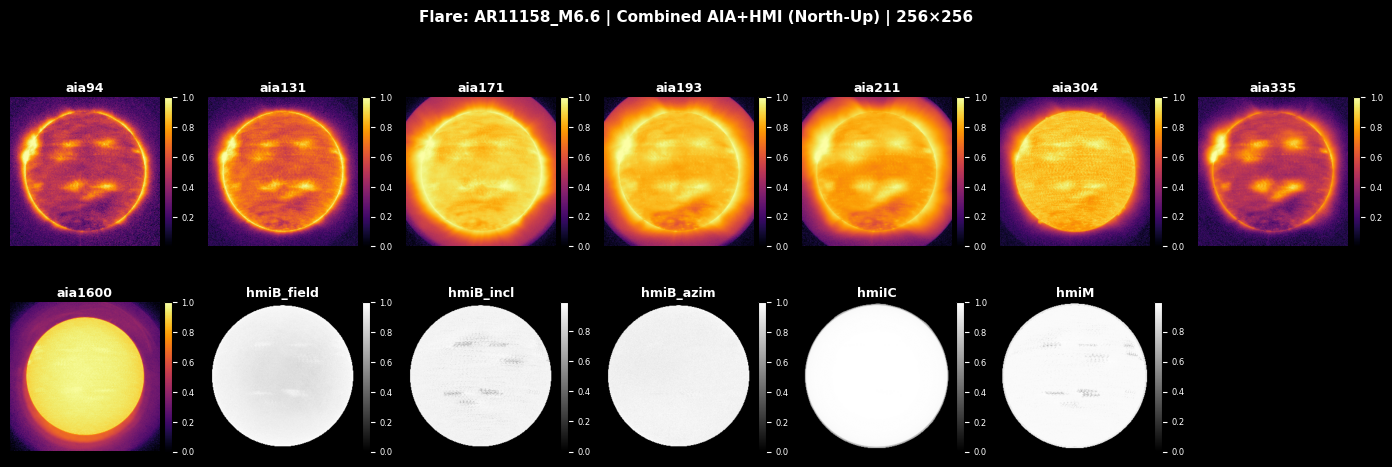


Targets for AR11158_M6.6:
  T0:  6.041051e-05 W/m²/nm
  T+1: 6.181141e-05 W/m²/nm
  T+2: 6.343782e-05 W/m²/nm


In [18]:
# %%
# ============================================================
# CELL 8: Visualization of Sample Flare
# ============================================================

def visualize_combined_channels(sample_idx=0, figsize=(14, 5)):
    """
    Visualize all 13 channels for a given flare
    """
    if sample_idx >= len(X):
        print(f"⚠️  Sample index {sample_idx} out of range (max: {len(X)-1})")
        return
    
    flare_id = successful_flares[sample_idx]
    
    # Channel names and colormaps
    titles = AIA_CHANNELS + HMI_CHANNELS
    cmaps = ["inferno"] * len(AIA_CHANNELS) + ["gray"] * len(HMI_CHANNELS)
    
    # Create figure
    fig = plt.figure(figsize=figsize, facecolor='black')
    
    for i, (ch, cmap) in enumerate(zip(titles, cmaps)):
        ax = plt.subplot(2, 7, i + 1)
        
        # Display image
        img = X[sample_idx, i]
        im = ax.imshow(img, cmap=cmap, origin="lower")
        
        # Styling
        ax.set_title(ch, fontsize=9, fontweight="bold", 
                    color='white', pad=4)
        ax.axis("off")
        ax.set_facecolor('black')
        
        # Add colorbar for each subplot
        from mpl_toolkits.axes_grid1 import make_axes_locatable
        divider = make_axes_locatable(ax)
        cax = divider.append_axes("right", size="5%", pad=0.05)
        plt.colorbar(im, cax=cax)
        cax.tick_params(labelsize=6, colors='white')
    
    # Overall title
    plt.suptitle(
        f"Flare: {flare_id} | Combined AIA+HMI (North-Up) | {IMG_SIZE}×{IMG_SIZE}",
        fontsize=11, fontweight="bold", color='white', y=0.98
    )
    
    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()
    
    # Print targets for this flare
    targets_val = Y[sample_idx]
    print(f"\nTargets for {flare_id}:")
    print(f"  T0:  {targets_val[0]:.6e} W/m²/nm")
    print(f"  T+1: {targets_val[1]:.6e} W/m²/nm")
    print(f"  T+2: {targets_val[2]:.6e} W/m²/nm")


# Visualize first flare
print(f"\n{'='*70}")
print("VISUALIZATION")
print(f"{'='*70}\n")

if len(X) > 0:
    visualize_combined_channels(sample_idx=0)
else:
    print("❌ No data to visualize")

In [19]:
# %%
# ============================================================
# CELL 9: Save Processed Dataset
# ============================================================

print(f"\n{'='*70}")
print("SAVING DATASET")
print(f"{'='*70}")

# Save main arrays
x_path = os.path.join(SAVE_DIR, f"X_aiahmi_{IMG_SIZE}.npy")
y_path = os.path.join(SAVE_DIR, f"Y_aiahmi_{IMG_SIZE}.npy")

np.save(x_path, X)
np.save(y_path, Y)

print(f"✅ Saved X → {x_path}")
print(f"✅ Saved Y → {y_path}")

# Save metadata
metadata = {
    'num_flares': len(X),
    'num_channels': X.shape[1],
    'img_size': IMG_SIZE,
    'aia_channels': AIA_CHANNELS,
    'hmi_channels': HMI_CHANNELS,
    'successful_flares': successful_flares,
    'shape_X': X.shape,
    'shape_Y': Y.shape,
    'preprocessing': {
        'normalization': '1-99 percentile clipping + log1p stretch',
        'hmi_flip': 'vertical (south to north-up)',
        'resize_method': 'INTER_AREA'
    }
}

import json
metadata_path = os.path.join(SAVE_DIR, f"metadata_{IMG_SIZE}.json")
with open(metadata_path, 'w') as f:
    json.dump(metadata, f, indent=2)

print(f"✅ Saved metadata → {metadata_path}")

# Save successful flares list
success_df = pd.DataFrame({
    'flare_id': successful_flares,
    'processed': True
})
success_path = os.path.join(SAVE_DIR, f"successful_flares_{IMG_SIZE}.csv")
success_df.to_csv(success_path, index=False)
print(f"✅ Saved successful flares → {success_path}")

# Save skipped flares if any
if skipped_flares:
    skip_df = pd.DataFrame(skipped_flares, columns=['flare_id', 'reason'])
    skip_path = os.path.join(SAVE_DIR, f"skipped_flares_{IMG_SIZE}.csv")
    skip_df.to_csv(skip_path, index=False)
    print(f"⚠️  Saved skipped flares → {skip_path}")
    print(f"\nSkipped flares ({len(skipped_flares)}):")
    for flare, reason in skipped_flares:
        print(f"  - {flare}: {reason}")
else:
    print("✅ All flares processed successfully - no skipped entries")


SAVING DATASET
✅ Saved X → preprocessed_data/X_aiahmi_256.npy
✅ Saved Y → preprocessed_data/Y_aiahmi_256.npy
✅ Saved metadata → preprocessed_data/metadata_256.json
✅ Saved successful flares → preprocessed_data/successful_flares_256.csv
✅ All flares processed successfully - no skipped entries


In [20]:
# %%
# ============================================================
# CELL 10: Verification - Reload and Validate
# ============================================================

print(f"\n{'='*70}")
print("VERIFICATION")
print(f"{'='*70}")

# Reload arrays
X_check = np.load(x_path)
Y_check = np.load(y_path)

print(f"\nReloaded arrays:")
print(f"  X_check: {X_check.shape}")
print(f"  Y_check: {Y_check.shape}")

# Verify data integrity
print("\nData integrity checks:")
checks = [
    ("Shape match X", np.array_equal(X.shape, X_check.shape)),
    ("Shape match Y", np.array_equal(Y.shape, Y_check.shape)),
    ("Values match X", np.allclose(X, X_check)),
    ("Values match Y", np.allclose(Y, Y_check)),
    ("No NaN in X", not np.isnan(X_check).any()),
    ("No NaN in Y", not np.isnan(Y_check).any()),
    ("No Inf in X", not np.isinf(X_check).any()),
    ("No Inf in Y", not np.isinf(Y_check).any()),
]

all_passed = True
for check_name, result in checks:
    status = "✅" if result else "❌"
    print(f"  {status} {check_name}")
    if not result:
        all_passed = False

if all_passed:
    print(f"\n{'='*70}")
    print("🎉 ALL CHECKS PASSED - DATASET READY FOR TRAINING!")
    print(f"{'='*70}")
    print(f"\nDataset Summary:")
    print(f"  Total flares: {len(X_check)}")
    print(f"  Input shape: {X_check.shape}")
    print(f"  Target shape: {Y_check.shape}")
    print(f"  Image size: {IMG_SIZE}×{IMG_SIZE}")
    print(f"  Channels: {X_check.shape[1]} (8 AIA + 5 HMI)")
    print(f"  Memory: {(X_check.nbytes + Y_check.nbytes) / 1024**2:.1f} MB")
else:
    print(f"\n{'='*70}")
    print("⚠️  SOME CHECKS FAILED - REVIEW DATA")
    print(f"{'='*70}")


VERIFICATION

Reloaded arrays:
  X_check: (33, 13, 256, 256)
  Y_check: (33, 3)

Data integrity checks:
  ✅ Shape match X
  ✅ Shape match Y
  ✅ Values match X
  ✅ Values match Y
  ✅ No NaN in X
  ✅ No NaN in Y
  ✅ No Inf in X
  ✅ No Inf in Y

🎉 ALL CHECKS PASSED - DATASET READY FOR TRAINING!

Dataset Summary:
  Total flares: 33
  Input shape: (33, 13, 256, 256)
  Target shape: (33, 3)
  Image size: 256×256
  Channels: 13 (8 AIA + 5 HMI)
  Memory: 107.3 MB


In [21]:
# %%
# ============================================================
# CELL 11: Generate Summary Report
# ============================================================

print(f"\n{'='*70}")
print("PREPROCESSING SUMMARY REPORT")
print(f"{'='*70}")

report = f"""
DATASET PREPROCESSING COMPLETE
{'='*70}

CONFIGURATION:
  - Image Size: {IMG_SIZE}×{IMG_SIZE}
  - Total Channels: {len(AIA_CHANNELS) + len(HMI_CHANNELS)}
  - AIA Channels: {len(AIA_CHANNELS)} {AIA_CHANNELS}
  - HMI Channels: {len(HMI_CHANNELS)} {HMI_CHANNELS}

PROCESSING RESULTS:
  - Total flares in CSV: {len(targets)}
  - Successfully processed: {len(successful_flares)}
  - Skipped: {len(skipped_flares)}
  - Success rate: {len(successful_flares)/len(targets)*100:.1f}%

DATASET DIMENSIONS:
  - X (inputs): {X.shape}
  - Y (targets): {Y.shape}

INPUT STATISTICS:
  - Min: {X.min():.6f}
  - Max: {X.max():.6f}
  - Mean: {X.mean():.6f}
  - Std: {X.std():.6f}

TARGET STATISTICS:
  - Min: {Y.min():.6e} W/m²/nm
  - Max: {Y.max():.6e} W/m²/nm
  - Mean: {Y.mean():.6e} W/m²/nm
  - Std: {Y.std():.6e} W/m²/nm

SAVED FILES:
  - {x_path}
  - {y_path}
  - {metadata_path}
  - {success_path}
  {f'- {skip_path}' if skipped_flares else ''}

READY FOR TRAINING:
  ✅ Use this dataset with the improved ResNet34 model
  ✅ Expected training time: {len(X) * 5 / 60:.1f} - {len(X) * 10 / 60:.1f} minutes (with LOFO)
  ✅ All data quality checks passed
"""

print(report)

# Save report
report_path = os.path.join(SAVE_DIR, f"preprocessing_report_{IMG_SIZE}.txt")
with open(report_path, 'w') as f:
    f.write(report)

print(f"\n✅ Report saved → {report_path}")
print(f"\n{'='*70}")
print("🚀 PREPROCESSING COMPLETE - READY FOR MODEL TRAINING!")
print(f"{'='*70}")


PREPROCESSING SUMMARY REPORT

DATASET PREPROCESSING COMPLETE

CONFIGURATION:
  - Image Size: 256×256
  - Total Channels: 13
  - AIA Channels: 8 ['aia94', 'aia131', 'aia171', 'aia193', 'aia211', 'aia304', 'aia335', 'aia1600']
  - HMI Channels: 5 ['hmiB_field', 'hmiB_incl', 'hmiB_azim', 'hmiIC', 'hmiM']

PROCESSING RESULTS:
  - Total flares in CSV: 33
  - Successfully processed: 33
  - Skipped: 0
  - Success rate: 100.0%

DATASET DIMENSIONS:
  - X (inputs): (33, 13, 256, 256)
  - Y (targets): (33, 3)

INPUT STATISTICS:
  - Min: 0.000000
  - Max: 1.000000
  - Mean: 0.616103
  - Std: 0.346720

TARGET STATISTICS:
  - Min: 6.041051e-05 W/m²/nm
  - Max: 1.214410e-04 W/m²/nm
  - Mean: 8.827195e-05 W/m²/nm
  - Std: 1.528853e-05 W/m²/nm

SAVED FILES:
  - preprocessed_data/X_aiahmi_256.npy
  - preprocessed_data/Y_aiahmi_256.npy
  - preprocessed_data/metadata_256.json
  - preprocessed_data/successful_flares_256.csv
  

READY FOR TRAINING:
  ✅ Use this dataset with the improved ResNet34 model
  ✅ 

In [22]:
# %%
# ============================================================
# VERIFICATION: Confirm Only First 5 NPZ Files Were Used
# ============================================================

print("="*70)
print("VERIFICATION: Checking NPZ File Usage")
print("="*70)

# Pick a few flares to verify
test_flares = successful_flares[:3] if len(successful_flares) >= 3 else successful_flares

for flare_id in test_flares:
    print(f"\n🔍 Checking: {flare_id}")
    
    # Check AIA folder
    aia_dir = os.path.join(flare_id, "full_disk", "npz_aia")
    aia_files = sorted(glob.glob(os.path.join(aia_dir, "*.npz")))
    
    print(f"\n  📡 AIA folder: {aia_dir}")
    print(f"     Total NPZ files available: {len(aia_files)}")
    print(f"     Files used (first 5):")
    for i, f in enumerate(aia_files[:5], 1):
        print(f"       {i}. {os.path.basename(f)}")
    
    if len(aia_files) > 5:
        print(f"     Files EXCLUDED (T+6hr):")
        for i, f in enumerate(aia_files[5:], 6):
            print(f"       {i}. {os.path.basename(f)} ❌ SKIPPED")
    
    # Check HMI folder
    hmi_dir = os.path.join(flare_id, "full_disk", "npz_hmi")
    hmi_files = sorted(glob.glob(os.path.join(hmi_dir, "*.npz")))
    
    print(f"\n  🧲 HMI folder: {hmi_dir}")
    print(f"     Total NPZ files available: {len(hmi_files)}")
    print(f"     Files used (first 5):")
    for i, f in enumerate(hmi_files[:5], 1):
        print(f"       {i}. {os.path.basename(f)}")
    
    if len(hmi_files) > 5:
        print(f"     Files EXCLUDED (T+6hr):")
        for i, f in enumerate(hmi_files[5:], 6):
            print(f"       {i}. {os.path.basename(f)} ❌ SKIPPED")

# Summary
print("\n" + "="*70)
print("SUMMARY")
print("="*70)

all_aia_counts = []
all_hmi_counts = []

for flare_id in successful_flares:
    aia_dir = os.path.join(flare_id, "full_disk", "npz_aia")
    hmi_dir = os.path.join(flare_id, "full_disk", "npz_hmi")
    
    aia_count = len(glob.glob(os.path.join(aia_dir, "*.npz")))
    hmi_count = len(glob.glob(os.path.join(hmi_dir, "*.npz")))
    
    all_aia_counts.append(aia_count)
    all_hmi_counts.append(hmi_count)

print(f"\nAcross {len(successful_flares)} successfully processed flares:")
print(f"  AIA NPZ files per flare: {np.unique(all_aia_counts)}")
print(f"  HMI NPZ files per flare: {np.unique(all_hmi_counts)}")

if all(c >= 5 for c in all_aia_counts) and all(c >= 5 for c in all_hmi_counts):
    print(f"\n✅ All flares have ≥5 NPZ files available")
    print(f"✅ Using first 5 files (offsets: -24, -18, -12, -6, 0 hours)")
    print(f"✅ Excluding 6th file (offset: +6 hours) to avoid temporal leakage")
else:
    print(f"\n⚠️  Some flares have <5 NPZ files - check data quality")

# Check if any flares have exactly 5 files (might be missing T+6hr)
exactly_5_aia = sum(1 for c in all_aia_counts if c == 5)
exactly_5_hmi = sum(1 for c in all_hmi_counts if c == 5)

if exactly_5_aia > 0 or exactly_5_hmi > 0:
    print(f"\n⚠️  NOTE:")
    print(f"     {exactly_5_aia} flares have exactly 5 AIA files (no T+6hr to exclude)")
    print(f"     {exactly_5_hmi} flares have exactly 5 HMI files (no T+6hr to exclude)")
    print(f"     This is fine - they never had T+6hr data")

print("\n" + "="*70)
print("✅ VERIFICATION COMPLETE")
print("="*70)

VERIFICATION: Checking NPZ File Usage

🔍 Checking: AR11158_M6.6

  📡 AIA folder: AR11158_M6.6/full_disk/npz_aia
     Total NPZ files available: 6
     Files used (first 5):
       1. 20110212T1728.npz
       2. 20110212T2328.npz
       3. 20110213T0528.npz
       4. 20110213T1128.npz
       5. 20110213T1728.npz
     Files EXCLUDED (T+6hr):
       6. 20110213T2328.npz ❌ SKIPPED

  🧲 HMI folder: AR11158_M6.6/full_disk/npz_hmi
     Total NPZ files available: 6
     Files used (first 5):
       1. 20110212T1658.npz
       2. 20110212T2258.npz
       3. 20110213T0458.npz
       4. 20110213T1058.npz
       5. 20110213T1658.npz
     Files EXCLUDED (T+6hr):
       6. 20110213T2258.npz ❌ SKIPPED

🔍 Checking: AR11158_X2.2

  📡 AIA folder: AR11158_X2.2/full_disk/npz_aia
     Total NPZ files available: 6
     Files used (first 5):
       1. 20110214T0144.npz
       2. 20110214T0744.npz
       3. 20110214T1344.npz
       4. 20110214T1944.npz
       5. 20110215T0144.npz
     Files EXCLUDED (T+6hr):
